In [7]:
# Necessary packages to run this file:
import spectral
import spectral.io.envi as envi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.image as img
from scipy.ndimage import gaussian_filter, zoom

In [8]:
path = '/n/archive/labs/hsi-data/everyday_objects/kitchen/'

folder_name1 = 'basmatiriisi'
file_number1 = '040'

folder_name2 = 'kuivahiiva'
file_number2 = '042'

folder_name3 = 'seesaminsiemen'
file_number3 = '044'

folder_name4 = "rikottu_ohrasuurimo"
file_number4 = "036"

In [9]:
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def openImage(file_path):
    try:
        image = envi.open(file_path)
        data = image.load()

        wavelengths = image.metadata.get('wavelength', None)
        if wavelengths:
            wavelengths = [float(w) for w in wavelengths]

        return data, wavelengths

    except Exception as e:
        print(f"  Error loading {file_path}: {e}")
        return None, None


# Data on nyt kuutio.
# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def load_and_compute_reflectance(path, folder_name, file_number):
    folder_path = path + folder_name + '/capture/'
    paths = {
        'raw':   os.path.join(folder_path, f"{file_number}.hdr"),
        'white': os.path.join(folder_path, f"WHITEREF_{file_number}.hdr"),
        'dark':  os.path.join(folder_path, f"DARKREF_{file_number}.hdr"),
    }

    for key, p in paths.items():
        if not os.path.isfile(p):
            print(f"  Missing {key} file: {p}")
            return None, None

    raw, wavelengths = openImage(paths['raw'])
    white, _ = openImage(paths['white'])
    dark, _  = openImage(paths['dark'])

    if any(x is None for x in [raw, white, dark]):
        print("  Failed to load one or more image cubes.")
        return None, None
    
    denominator = white - dark
    denominator[denominator == 0] = 1e-6

    # np.clip: limits the values between given given values, here 0 and 1
    reflectance = np.clip((raw - dark) / denominator, 0, 1)
    return reflectance, wavelengths

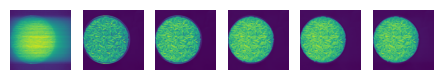

/tmp/ipykernel_72408/2659818352.py:41: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_72408/2659818352.py:45: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


In [ ]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/040.hdr')

cube_raw = np.array(data_raw.asarray())

i = 6

for p in range(0, i):
    plt.subplot(1, i+1, p+1)
    plt.imshow(cube_raw[:,:,int(p*(204/i))])
    plt.axis('off')

plt.show()

/tmp/ipykernel_72408/2659818352.py:41: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  denominator = white - dark
/tmp/ipykernel_72408/2659818352.py:45: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reflectance = np.clip((raw - dark) / denominator, 0, 1)


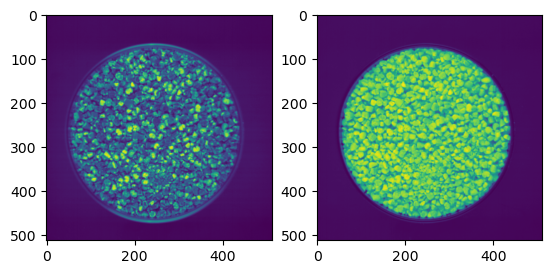

(11, 184)

In [30]:
cube, waves = load_and_compute_reflectance(path, folder_name4, file_number4)

# From https://forge.inrae.fr/arnogermond/hsi-processing-python/-/blob/main/notebooks/1_hsi_processing.ipynb?ref_type=heads
def minMaxReflectance(cube, draw=True):
    min = int(np.argmin(np.mean(cube, axis=(0, 1))))
    max = int(np.argmax(np.mean(cube, axis=(0, 1))))
    if draw:
        plt.subplot(1, 2, 1)
        plt.imshow(cube[:,:,8])
        plt.subplot(1, 2, 2)
        plt.imshow(cube[:,:,155])
        plt.show()
    return min, max


minMaxReflectance(cube)

In [32]:
'''
def cropImage(cube, top=100, bottom=100):
    h = cube.shape[0]
    w = cube.shape[1]
    print(w)
    if top + bottom >= h:
        raise ValueError(
            f"Crop size ({top}+{bottom}) exceeds image height ({h})"
        )
    return cube[top:h - bottom, :w - 140, :]


cube = cropImage(cube)
plt.imshow(cube[:,:,155])
plt.show()
'''

'\ndef cropImage(cube, top=100, bottom=100):\n    h = cube.shape[0]\n    w = cube.shape[1]\n    print(w)\n    if top + bottom >= h:\n        raise ValueError(\n            f"Crop size ({top}+{bottom}) exceeds image height ({h})"\n        )\n    return cube[top:h - bottom, :w - 140, :]\n\n\ncube = cropImage(cube)\nplt.imshow(cube[:,:,155])\nplt.show()\n'